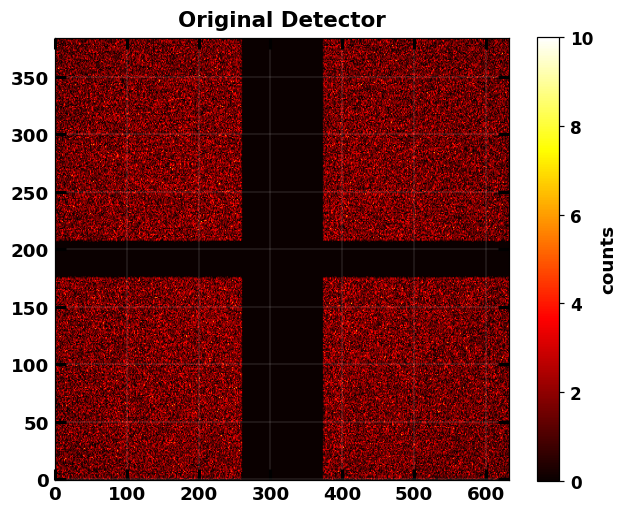

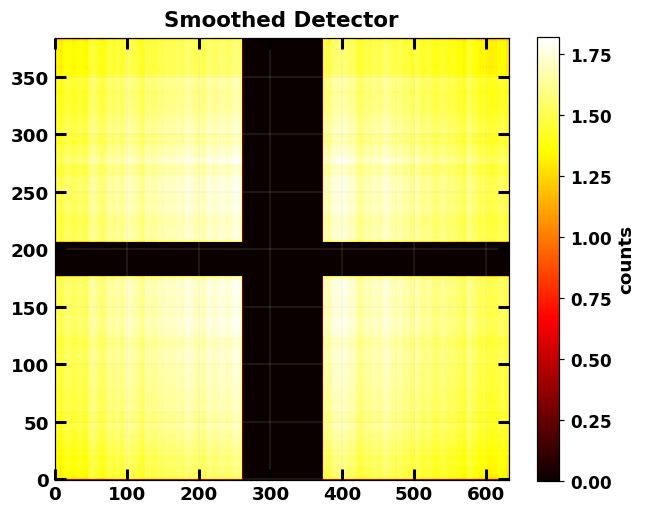

289567.0 289566.99999999994


In [1]:
import numpy as np

from bloodmoon.mask import codedmask, count

from darksun.data import get_data
from darksun.show import image_plot
from darksun.optim import bkg_smoothing

basepath = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'
datapath = f'{basepath}/IROSDummy/CXB_infdet_2-50keV_1ks_cam1a_detected.fits'

#basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
#maskpath = f'{basepath}/wfm_mask_summer2021.fits'
#datapath = f'{basepath}/IROSDummy/CXB_1ks_detected_2-50keV.fits'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
sdl = get_data(datapath)

detector = count(wfm, sdl.DLdata)[0]

ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
image_plot(
    detector,
    title='Original Detector',
    cbarlabel='counts',
    cmap='hot',
    aspect=ASPECT,
)

smoothed = bkg_smoothing(detector, wfm)

image_plot(
    smoothed,
    title='Smoothed Detector',
    cbarlabel='counts',
    cmap='hot',
    aspect=ASPECT,
)

print(detector.sum(), smoothed.sum())

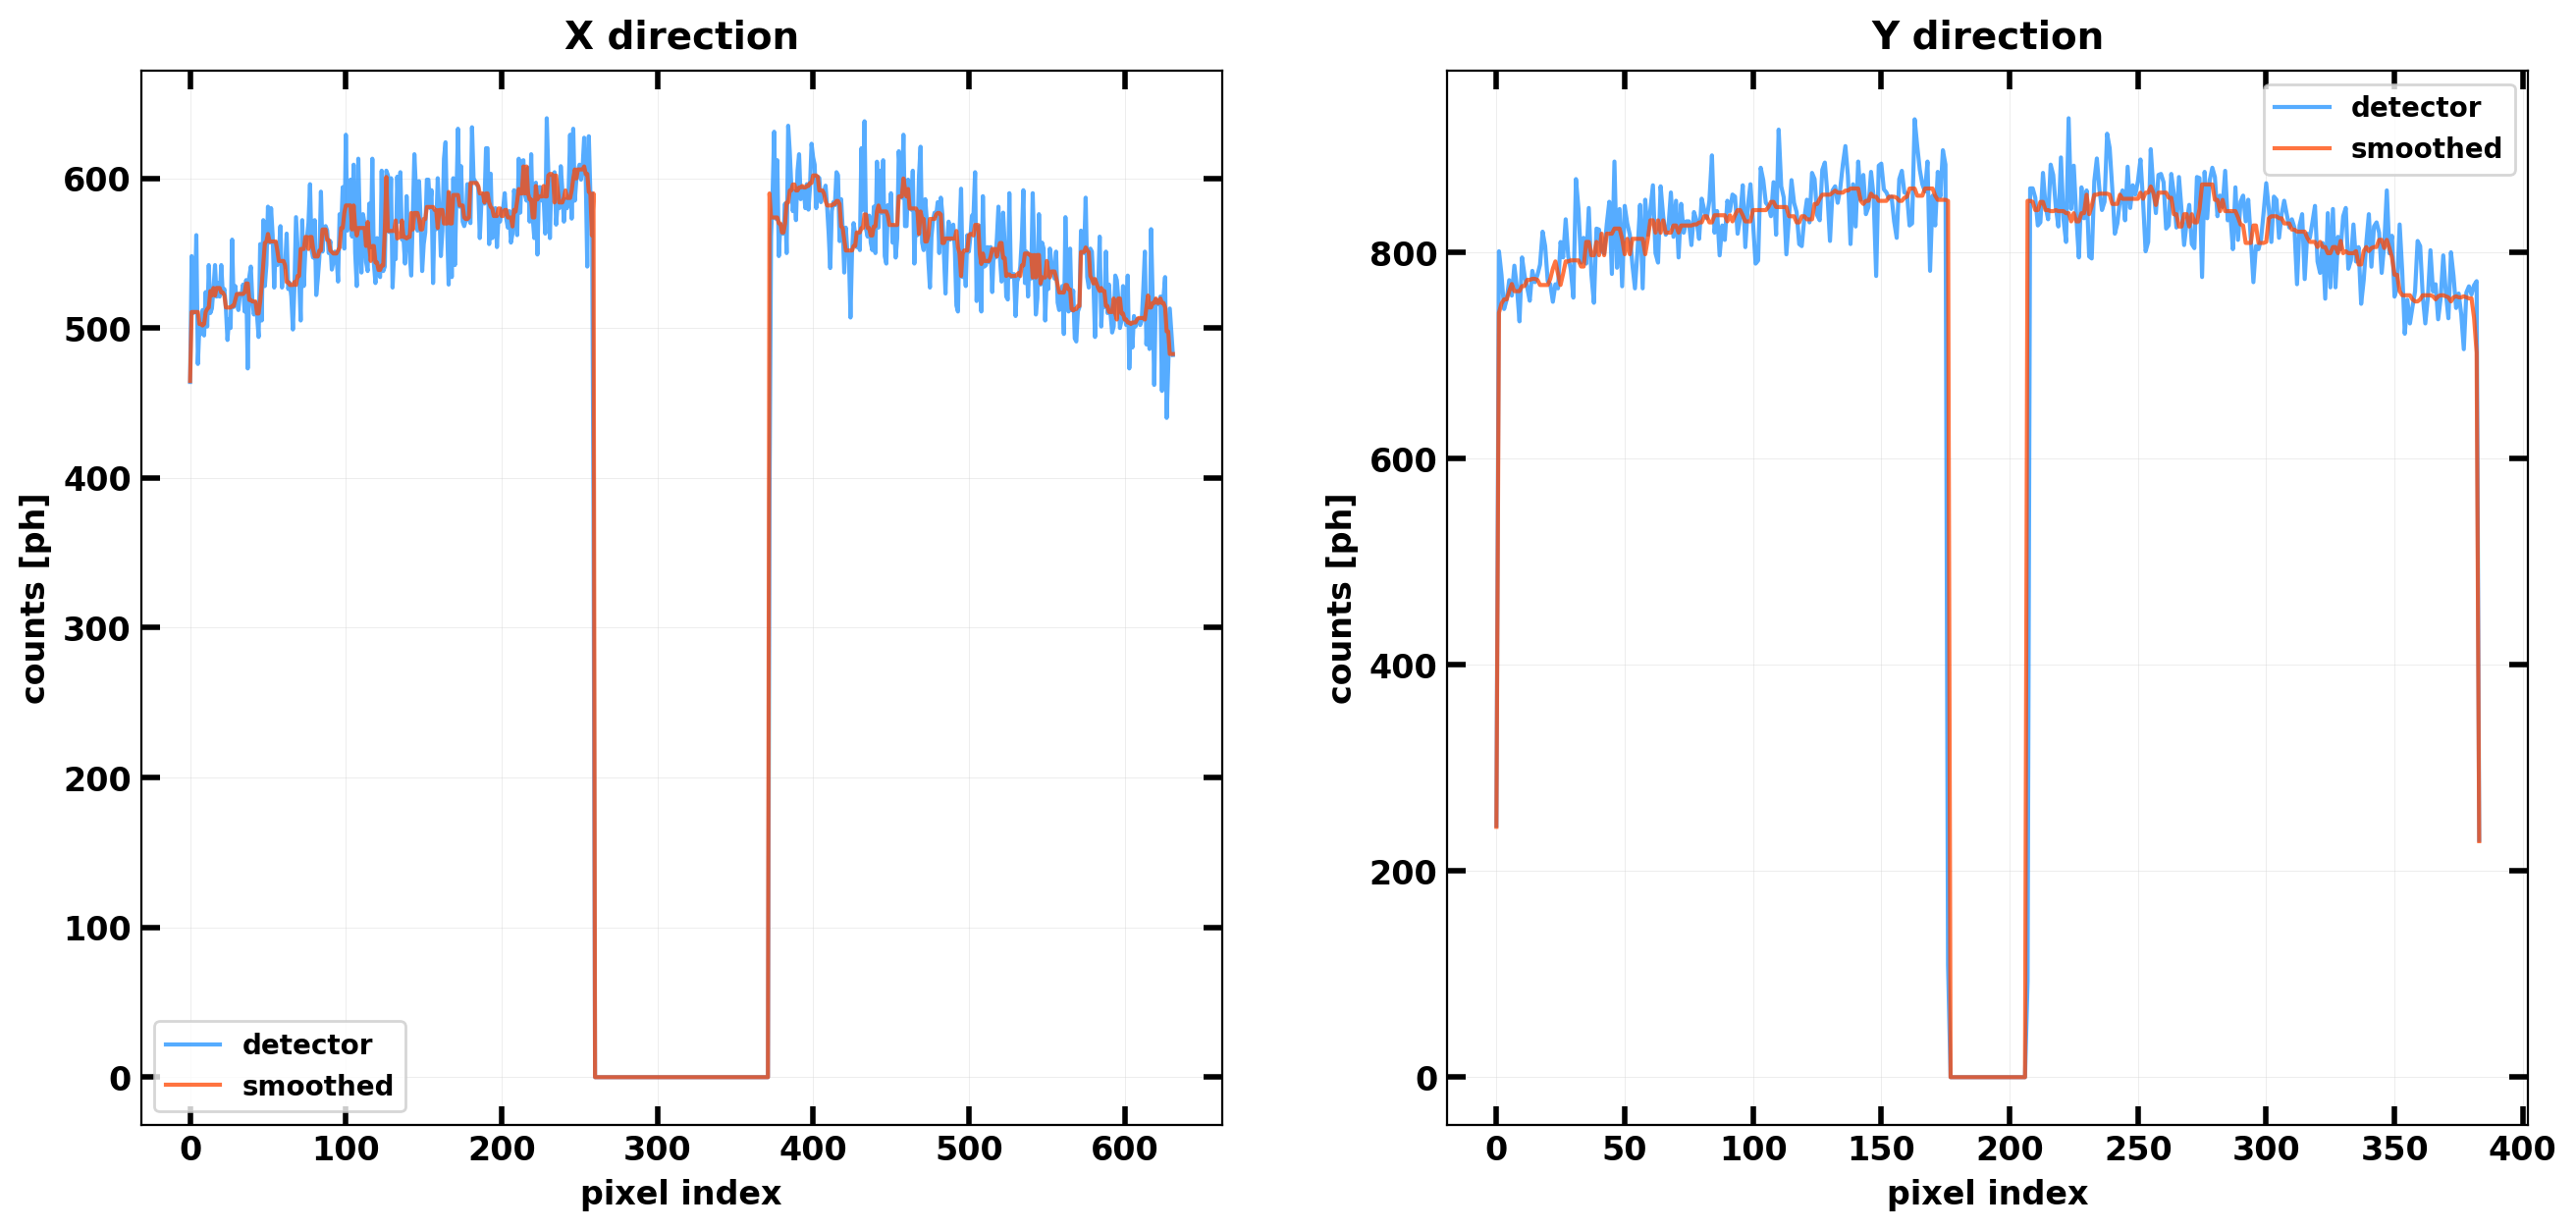

In [2]:
from darksun.show import map4biplot, biplot

collapsed_det_x, collapsed_smoothed_x = map(
    lambda x: np.sum(x, axis=0),
    (detector, smoothed),
)
dmapx = map4biplot(
    arrs=(collapsed_det_x, collapsed_smoothed_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'OrangeRed')
)

collapsed_det_y, collapsed_smoothed_y = map(
    lambda x: np.sum(x, axis=1),
    (detector, smoothed),
)
dmapy = map4biplot(
    arrs=(collapsed_det_y, collapsed_smoothed_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'OrangeRed')
)

biplot(dmapx, dmapy)

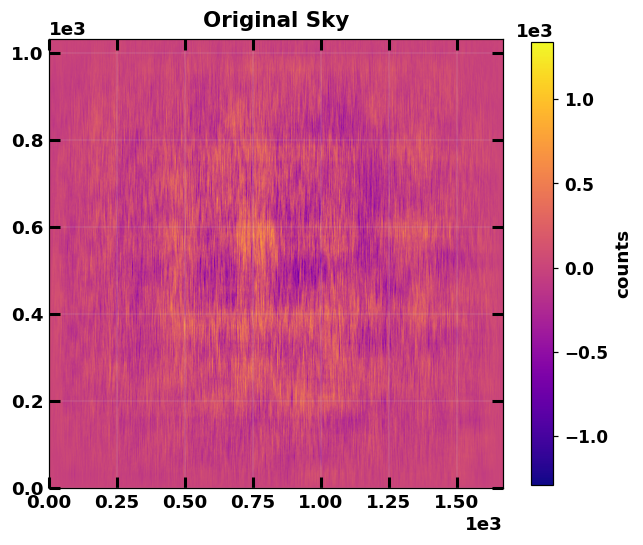

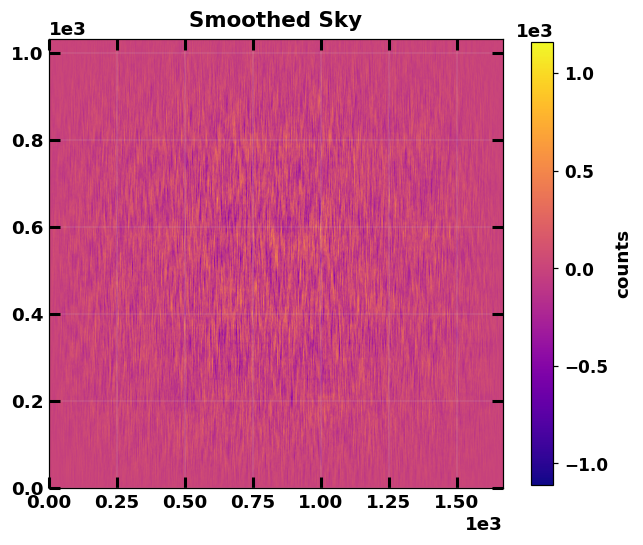

In [3]:
from bloodmoon.mask import decode, variance

sky = decode(wfm, detector)
smoothed_sky = decode(wfm, detector - smoothed)

image_plot(
    sky,
    title='Original Sky',
    cbarlabel='counts',
    cmap='plasma',
    aspect=ASPECT,
)
image_plot(
    smoothed_sky,
    title='Smoothed Sky',
    cbarlabel='counts',
    cmap='plasma',
    aspect=ASPECT,
)

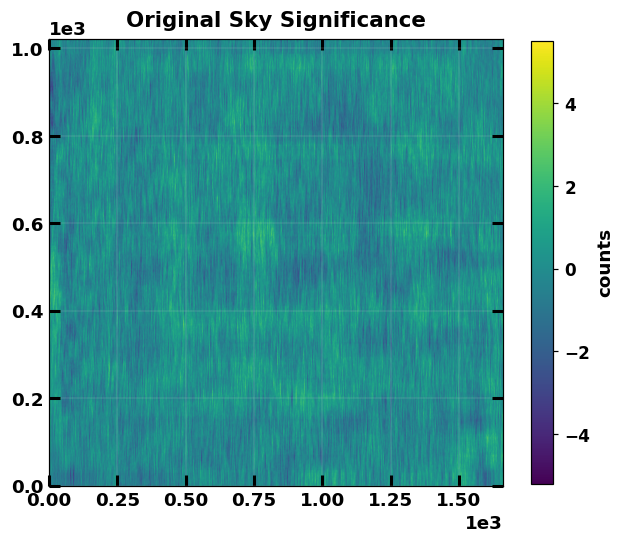

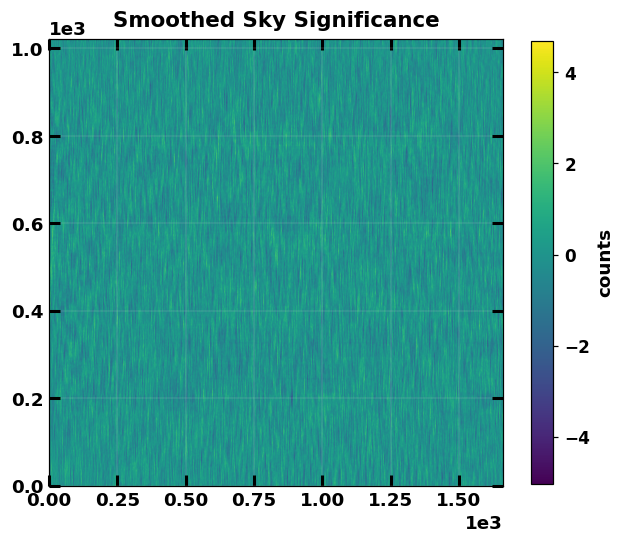

In [9]:
varmap = np.clip(variance(wfm, detector), a_min=1e-8, a_max=detector.sum())

YLIM, YLIM = 10, 5
significance = (sky / np.sqrt(varmap))[YLIM : -YLIM, YLIM : -YLIM]
smoothed_significance = (smoothed_sky / np.sqrt(varmap))[YLIM : -YLIM, YLIM : -YLIM]

image_plot(
    significance,
    title='Original Sky Significance',
    cbarlabel='counts',
    cmap='viridis',
    aspect=ASPECT,
)
image_plot(
    smoothed_significance,
    title='Smoothed Sky Significance',
    cbarlabel='counts',
    cmap='viridis',
    aspect=ASPECT,
)

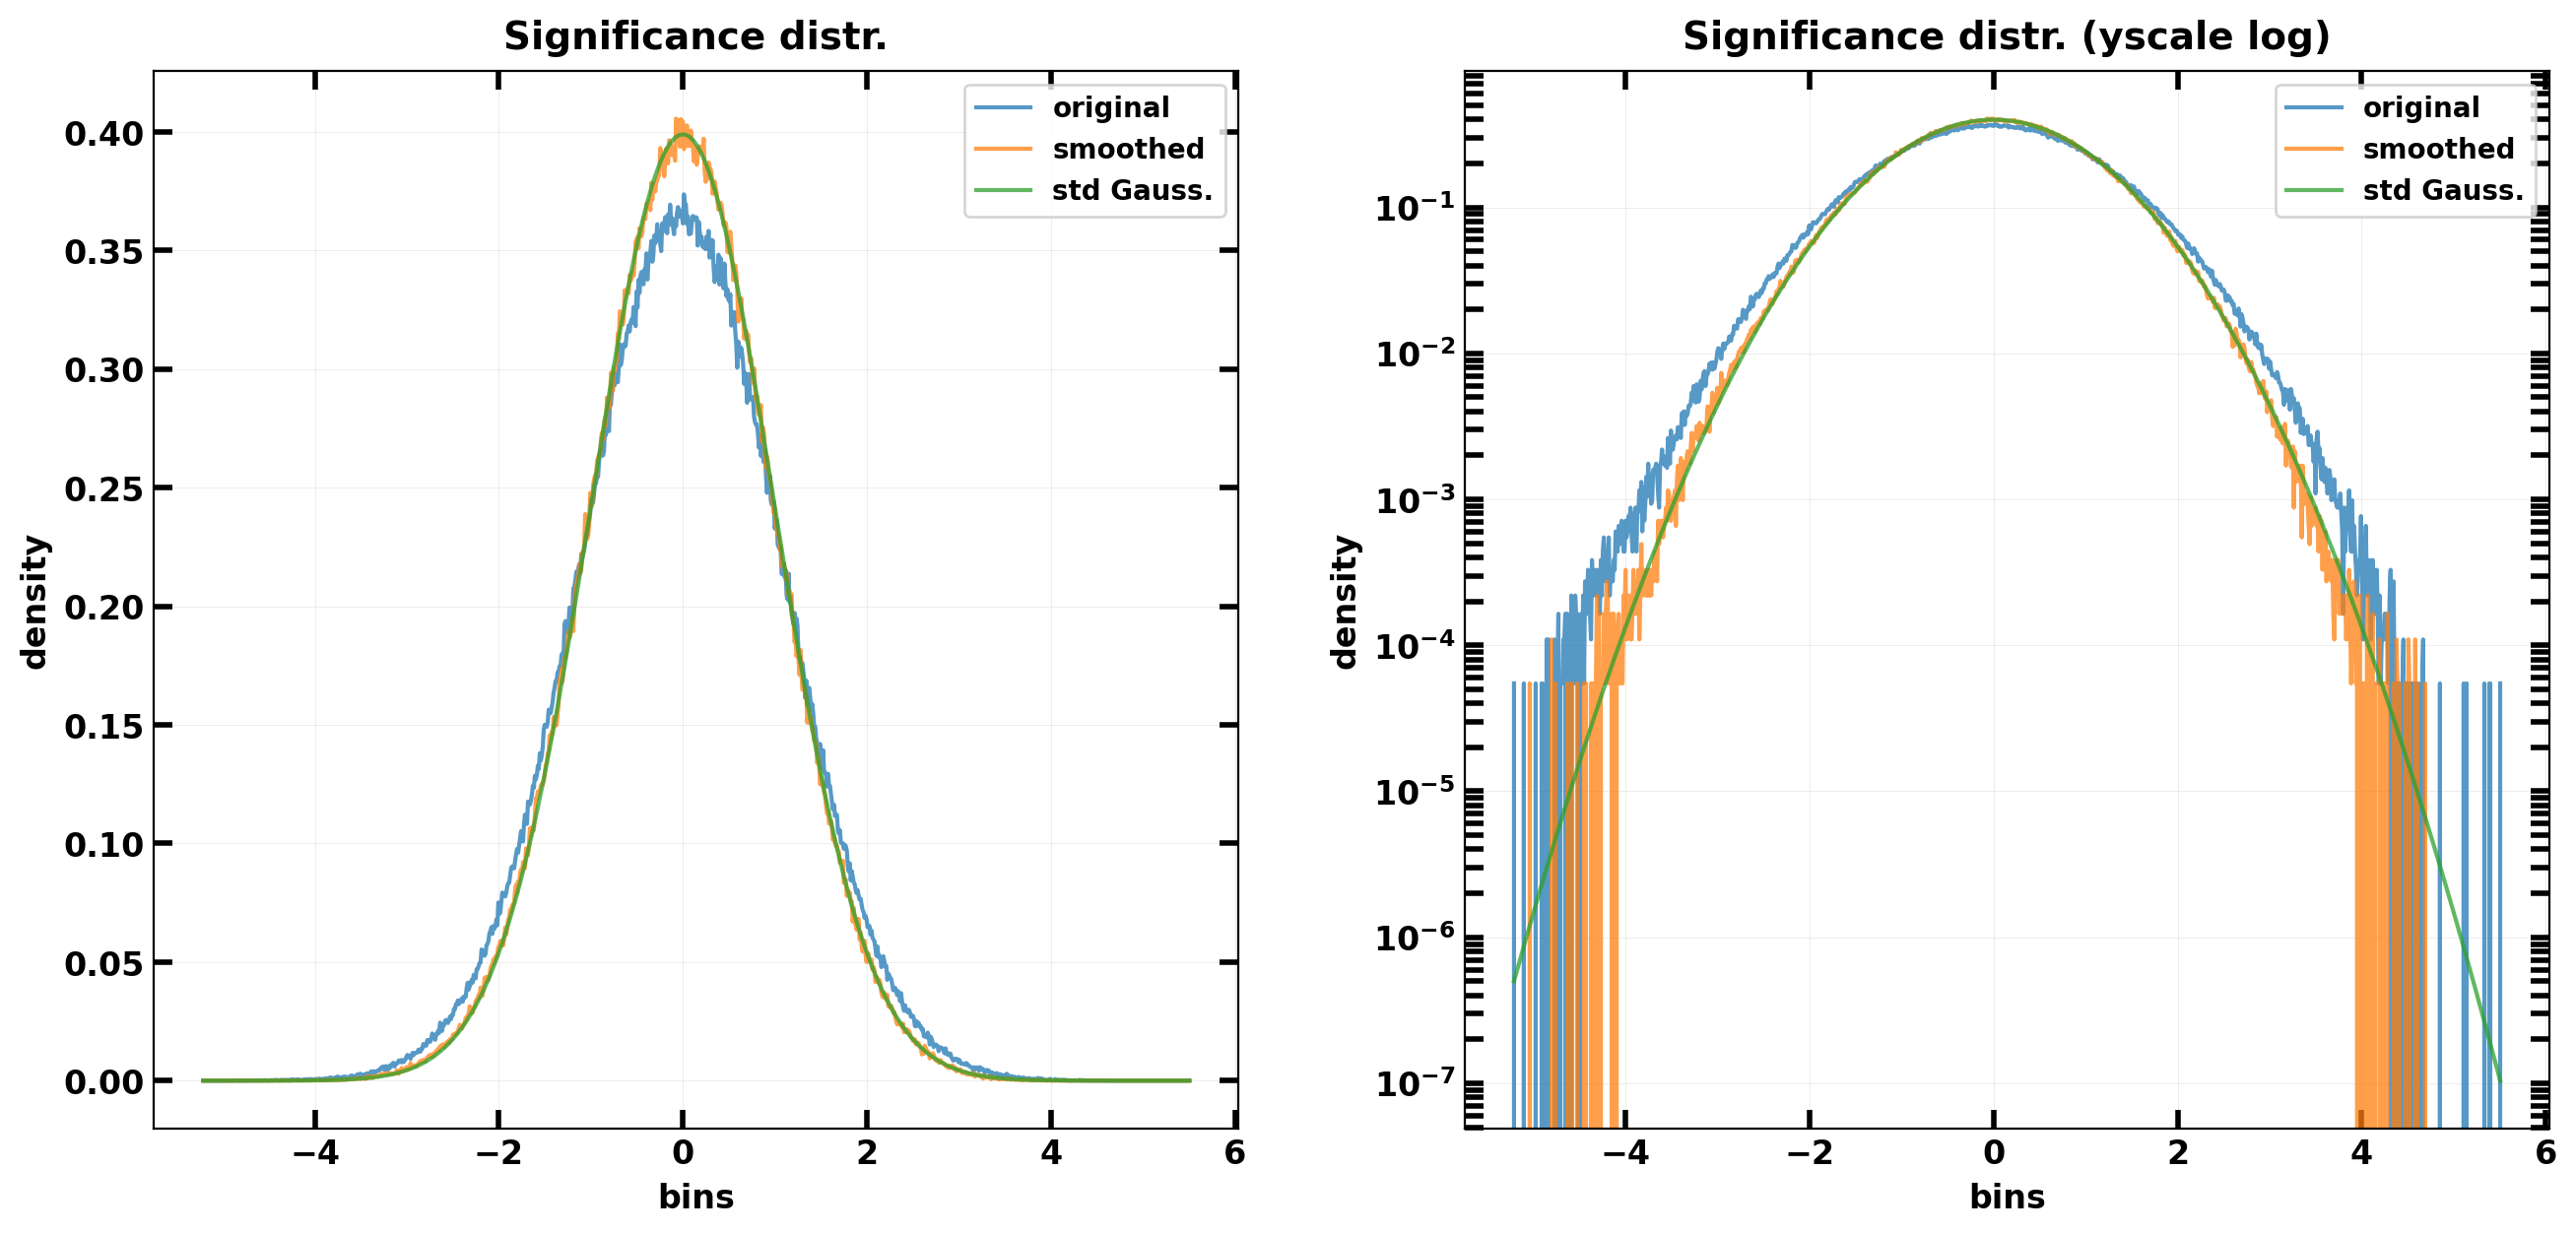

In [10]:
from numpy.typing import NDArray

def Gaussian(x: NDArray, x0: float = 0.0, sigma: float = 1.0) -> NDArray:
    """Returns a Gaussian distribution centered around `x0` and with std `sigma`."""
    return (
        1.0 / np.sqrt(2 * np.pi * np.square(sigma)) * np.exp(-np.square(x - x0) / (2 * np.square(sigma)))
    )

hist_signf, bins = np.histogram(significance, bins=1000, density=True)
hist_smoothed_signf, _ = np.histogram(smoothed_significance, bins=bins, density=True)

bins = bins[:-1]

dmap1 = map4biplot(
    arrs=(
        hist_signf, hist_smoothed_signf, Gaussian(bins),
    ),
    title='Significance distr.',
    xlabel='bins',
    ylabel='density',
    labels=(
        'original', 'smoothed', 'std Gauss.',
    ),
    x=bins,
    style='plot',
)
dmap2 = map4biplot(
    arrs=(
        hist_signf, hist_smoothed_signf, Gaussian(bins),
    ),
    title='Significance distr. (yscale log)',
    xlabel='bins',
    ylabel='density',
    labels=(
        'original', 'smoothed', 'std Gauss.',
    ),
    x=bins,
    style='plot',
    yscale='log',
)
biplot(dmap1, dmap2)

In [6]:
np.std(significance), np.std(smoothed_significance)

(np.float64(1.0939785053046587), np.float64(1.0038833306833503))